In [9]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

In [3]:
# mount the drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/colab/test/covid_dataset.csv")

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort properly (VERY IMPORTANT)
df = df.sort_values(by=['Location', 'Date'])

print(df.shape)
df.head()

(330327, 57)


,Date,Location,Lat,Long,Cumulative_Cases,Daily_New,Trend_7d,Growth_Factor,Acceleration,Velocity,...,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline,mobility_index,lockdown_indicator,mobility_trend_7day,mobility_growth_rate,variant,num_sequences,num_sequences_total
0,2020-01-22,Afghanistan - Afghanistan,33.93911,67.709953,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Original,0.0,0.0
1,2020-01-23,Afghanistan - Afghanistan,33.93911,67.709953,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Original,0.0,0.0
2,2020-01-24,Afghanistan - Afghanistan,33.93911,67.709953,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Original,0.0,0.0
3,2020-01-25,Afghanistan - Afghanistan,33.93911,67.709953,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Original,0.0,0.0
4,2020-01-26,Afghanistan - Afghanistan,33.93911,67.709953,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Original,0.0,0.0


# Global Model

In [16]:
# Remove rows with all zero early noise (optional but helpful)
df = df[df['Days_Since_Start'] >= 0]

# Fill missing values
df = df.fillna(method='ffill').fillna(0)

# Encode Location
le_location = LabelEncoder()
df['Location_encoded'] = le_location.fit_transform(df['Location'])

# Encode variant
df['variant'] = df['variant'].astype(str)
le_variant = LabelEncoder()
df['variant_encoded'] = le_variant.fit_transform(df['variant'])


features = [
    'Location_encoded',
    
    'Lag_7', 'Lag_14',
    'Trend_7d', 'Growth_Factor',
    'Acceleration', 'Velocity',
    
    'mobility_index',
    'mobility_trend_7day',
    'mobility_growth_rate',
    
    'lockdown_indicator',
    
    'Day_of_Week',
    'Month',
    
    'variant_encoded'
]

target = 'Daily_Cases'

X = df[features]
y = df[target]

/tmp/ipykernel_2123/4173675290.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(0)


In [17]:
split_date = "2022-07-01"

train_mask = df['Date'] < split_date

X_train = X[train_mask]
X_test  = X[~train_mask]

y_train = y[train_mask]
y_test  = y[~train_mask]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Train size: (235454, 14)
Test size: (72557, 14)


MAE: 200.0221350692615
RMSE: 3094.038404580767


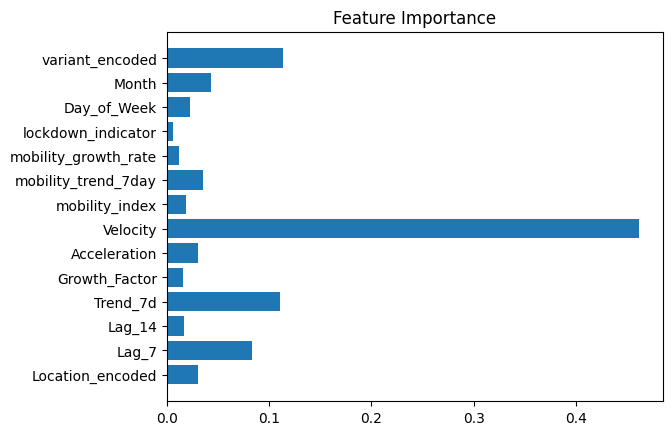

In [18]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

importance = model.feature_importances_

plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

# Country wise train

/tmp/ipykernel_2123/1716829016.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.ffill().fillna(0))


Total countries: 288

Training complete.
Models trained: 287
Countries skipped: 1


,Country,Train_Rows,Test_Rows,MAE,RMSE,Status
0,United Kingdom - Pitcairn Islands,0,233,NaN,NaN,Skipped (not enough data)
1,Antarctica - Antarctica,199,252,0.000000,0.000000,Trained
2,Canada - Repatriated Travellers,584,252,0.000000,0.000000,Trained
3,Holy See - Holy See,847,252,0.000000,0.000000,Trained
4,Summer Olympics 2020 - Summer Olympics 2020,377,252,0.000000,0.000000,Trained
5,Canada - Grand Princess,840,252,0.000001,0.000001,Trained
6,Canada - Diamond Princess,791,252,0.000002,0.000002,Trained
7,Diamond Princess - Diamond Princess,875,252,0.000013,0.000015,Trained
8,"Korea, North - Korea, North",48,252,0.000027,0.000027,Trained
9,MS Zaandam - MS Zaandam,825,252,0.000020,0.000030,Trained



Average MAE: 232.5715450922139
Average RMSE: 613.6684359211273


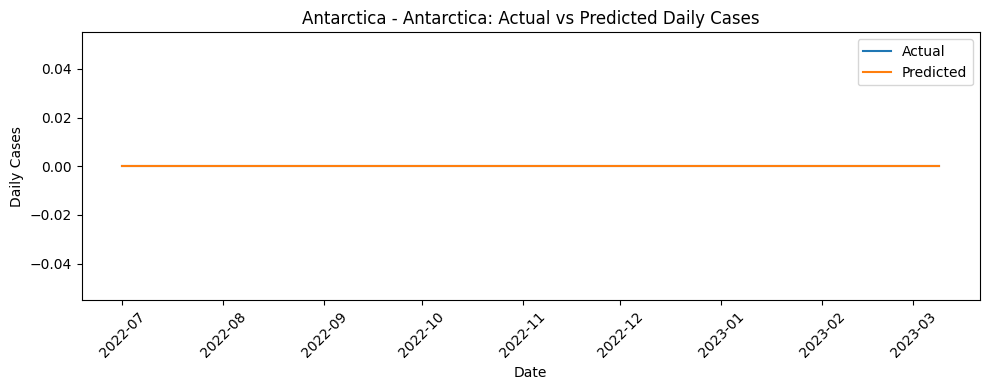

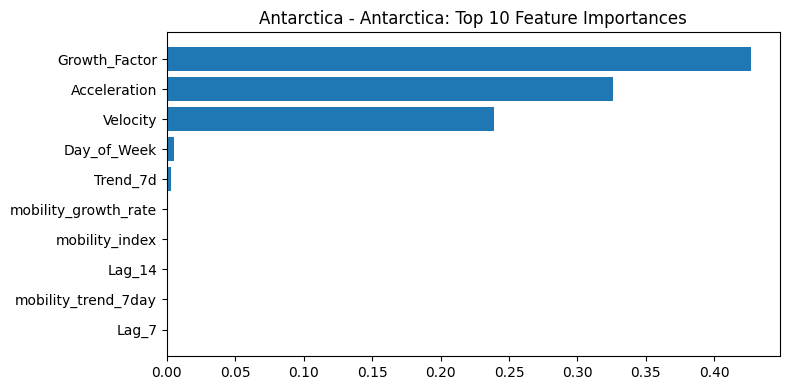

In [19]:
df = df.sort_values(["Location", "Date"]).reset_index(drop=True)

# Optional: remove noisy rows
if "Days_Since_Start" in df.columns:
    df = df[df["Days_Since_Start"] >= 0].copy()

# Forward-fill missing values within each country, then fill remaining with 0
df = (
    df.groupby("Location", group_keys=False)
      .apply(lambda g: g.ffill().fillna(0))
      .reset_index(drop=True)
)

# Encode variant globally (same mapping for all countries)
df["variant"] = df["variant"].astype(str)
le_variant = LabelEncoder()
df["variant_encoded"] = le_variant.fit_transform(df["variant"])

# =========================
# 3) Feature setup
# =========================
target = "Daily_Cases"

# Country-wise training => Location is not needed as feature
features = [
    "Lag_7", "Lag_14",
    "Trend_7d", "Growth_Factor",
    "Acceleration", "Velocity",
    "mobility_index",
    "mobility_trend_7day",
    "mobility_growth_rate",
    "lockdown_indicator",
    "Day_of_Week", "Month",
    "variant_encoded"
]

# Keep only rows where all required columns exist and target is present
required_cols = ["Location", "Date", target] + features
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

df = df.dropna(subset=[target]).copy()

# =========================
# 4) Train/Test split date
# =========================
split_date = pd.to_datetime("2022-07-01")

# =========================
# 5) Train one model per country
# =========================
models_by_country = {}
predictions_by_country = {}
metrics_rows = []
feature_importance_by_country = {}

min_train_rows = 30
min_test_rows = 7

countries = sorted(df["Location"].unique())
print(f"Total countries: {len(countries)}")

for country in countries:
    cdf = df[df["Location"] == country].copy().sort_values("Date")

    train_mask = cdf["Date"] < split_date
    test_mask = ~train_mask

    train_df = cdf[train_mask]
    test_df = cdf[test_mask]

    if len(train_df) < min_train_rows or len(test_df) < min_test_rows:
        metrics_rows.append({
            "Country": country,
            "Train_Rows": len(train_df),
            "Test_Rows": len(test_df),
            "MAE": np.nan,
            "RMSE": np.nan,
            "Status": "Skipped (not enough data)"
        })
        continue

    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Optional: cases cannot be negative
    y_pred = np.clip(y_pred, 0, None)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    models_by_country[country] = model
    predictions_by_country[country] = pd.DataFrame({
        "Date": test_df["Date"].values,
        "Actual": y_test.values,
        "Predicted": y_pred
    })

    feature_importance_by_country[country] = pd.Series(
        model.feature_importances_, index=features
    ).sort_values(ascending=False)

    metrics_rows.append({
        "Country": country,
        "Train_Rows": len(train_df),
        "Test_Rows": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Status": "Trained"
    })

# =========================
# 6) Metrics summary
# =========================
metrics_df = pd.DataFrame(metrics_rows).sort_values(
    by=["Status", "RMSE"], ascending=[True, True]
).reset_index(drop=True)

print("\nTraining complete.")
print(f"Models trained: {len(models_by_country)}")
print(f"Countries skipped: {(metrics_df['Status'] != 'Trained').sum()}")

display(metrics_df.head(20))

# Overall average on trained countries
trained_metrics = metrics_df[metrics_df["Status"] == "Trained"]
if len(trained_metrics) > 0:
    print("\nAverage MAE:", trained_metrics["MAE"].mean())
    print("Average RMSE:", trained_metrics["RMSE"].mean())

# =========================
# 7) Example: plot predictions for one country
# =========================
example_country = trained_metrics.iloc[0]["Country"] if len(trained_metrics) > 0 else None

if example_country:
    plot_df = predictions_by_country[example_country].copy()

    plt.figure(figsize=(10, 4))
    plt.plot(plot_df["Date"], plot_df["Actual"], label="Actual")
    plt.plot(plot_df["Date"], plot_df["Predicted"], label="Predicted")
    plt.title(f"{example_country}: Actual vs Predicted Daily Cases")
    plt.xlabel("Date")
    plt.ylabel("Daily Cases")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Top feature importance for this country
    fi = feature_importance_by_country[example_country].head(10).sort_values()
    plt.figure(figsize=(8, 4))
    plt.barh(fi.index, fi.values)
    plt.title(f"{example_country}: Top 10 Feature Importances")
    plt.tight_layout()
    plt.show()

# =========================
# 8) Predict helper function
# =========================
def predict_country(country_name, input_df):
    """
    input_df must contain the same feature columns used in training.
    Returns predictions for the given country model.
    """
    if country_name not in models_by_country:
        raise ValueError(f"No trained model found for country: {country_name}")
    model = models_by_country[country_name]
    return model.predict(input_df[features])

# ARIMA model

Total locations after filtering: 281

Training complete.
Trained: 264
Skipped: 17
Failed : 0


,Country,Train_Rows,Test_Rows,NonZero_Train_Days,Train_STD,Order,MAE,RMSE,Status
0,Antarctica - Antarctica,199,252,1,0.777808,None,NaN,NaN,Skipped (low signal / low data)
1,China - Guizhou,891,252,50,1.296887,None,NaN,NaN,Skipped (low signal / low data)
2,China - Hainan,891,252,52,1.704775,None,NaN,NaN,Skipped (low signal / low data)
3,China - Ningxia,891,252,46,0.680470,None,NaN,NaN,Skipped (low signal / low data)
4,China - Qinghai,888,252,36,1.200913,None,NaN,NaN,Skipped (low signal / low data)
5,China - Tibet,883,252,1,0.033634,None,NaN,NaN,Skipped (low signal / low data)
6,France - Wallis and Futuna,620,252,49,3.959381,None,NaN,NaN,Skipped (low signal / low data)
7,Holy See - Holy See,847,252,13,0.379534,None,NaN,NaN,Skipped (low signal / low data)
8,"Korea, North - Korea, North",48,252,1,0.142826,None,NaN,NaN,Skipped (low signal / low data)
9,Marshall Islands - Marshall Islands,611,252,7,0.353632,None,NaN,NaN,Skipped (low signal / low data)



Average MAE : 0.003972214043157188
Average RMSE: 0.01553749624846409


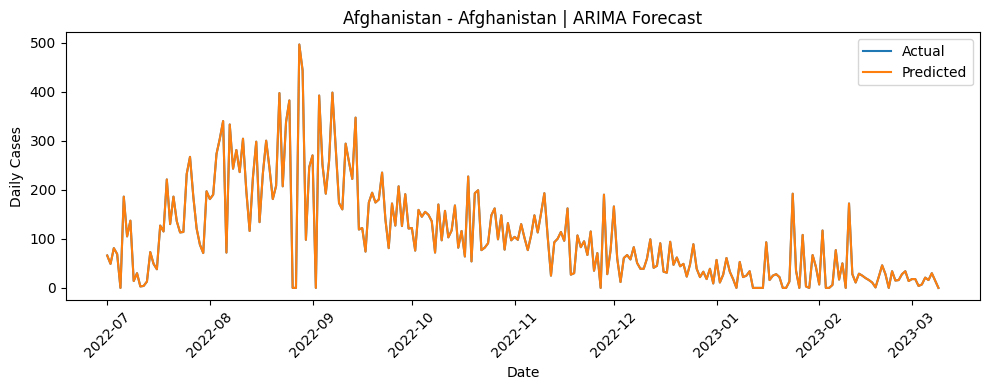

In [20]:
# =========================
# ARIMA Country-wise Training (ARIMAX with exogenous features)
# =========================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# -------------------------
# 1) Load + basic prep
# -------------------------
# If df already exists in notebook, this will reuse it.
# Otherwise uncomment one of the load lines below.

# df = pd.read_csv("/content/drive/MyDrive/colab/test/covid_dataset.csv")
# df = pd.read_csv("data/covid_dataset.csv")

df_arima = df.copy()
df_arima["Date"] = pd.to_datetime(df_arima["Date"])
df_arima = df_arima.sort_values(["Location", "Date"]).reset_index(drop=True)

if "Days_Since_Start" in df_arima.columns:
    df_arima = df_arima[df_arima["Days_Since_Start"] >= 0].copy()

# Country-wise forward fill
df_arima = (
    df_arima.groupby("Location", group_keys=False)
    .apply(lambda g: g.ffill().fillna(0))
    .reset_index(drop=True)
)

# Encode variant
if "variant_encoded" not in df_arima.columns:
    df_arima["variant"] = df_arima["variant"].astype(str)
    le_variant = LabelEncoder()
    df_arima["variant_encoded"] = le_variant.fit_transform(df_arima["variant"])

# -------------------------
# 2) Config
# -------------------------
target = "Daily_Cases"
split_date = pd.to_datetime("2022-07-01")

exog_features = [
    "Lag_7", "Lag_14",
    "Trend_7d", "Growth_Factor",
    "Acceleration", "Velocity",
    "mobility_index",
    "mobility_trend_7day",
    "mobility_growth_rate",
    "lockdown_indicator",
    "Day_of_Week", "Month",
    "variant_encoded"
]

required_cols = ["Location", "Date", target] + exog_features
missing_cols = [c for c in required_cols if c not in df_arima.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

df_arima = df_arima.dropna(subset=[target]).copy()

# Optional: remove known non-country entities (edit as needed)
exclude_keywords = [
    "Olympics", "Diamond Princess", "Grand Princess",
    "Repatriated Travellers", "MS Zaandam"
]
mask_exclude = df_arima["Location"].astype(str).str.contains("|".join(exclude_keywords), case=False, na=False)
df_arima = df_arima[~mask_exclude].copy()

# Eligibility thresholds to reduce overfitting on sparse countries
min_train_rows = 180
min_test_rows = 30
min_nonzero_train_days = 60
min_train_std = 1e-6

# Small order search space (faster + stable)
candidate_orders = [
    (1, 0, 1), (1, 1, 1),
    (2, 0, 1), (2, 1, 1),
    (2, 1, 2)
]

# -------------------------
# 3) Helpers
# -------------------------
def choose_best_arima_order(y_train, exog_train, orders):
    """
    Pick best ARIMA order by AIC on train data.
    Returns (best_order, best_fit) or (None, None).
    """
    best_aic = np.inf
    best_order = None
    best_fit = None

    for order in orders:
        try:
            model = ARIMA(
                endog=y_train,
                exog=exog_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = order
                best_fit = fit
        except Exception:
            continue

    return best_order, best_fit


def country_quality_checks(train_df, y_col):
    y_train = train_df[y_col].astype(float)
    return {
        "train_rows": len(train_df),
        "nonzero_days": int((y_train > 0).sum()),
        "train_std": float(y_train.std(ddof=0))
    }

# -------------------------
# 4) Train per country
# -------------------------
models_by_country = {}
order_by_country = {}
predictions_by_country = {}
metrics_rows = []

countries = sorted(df_arima["Location"].unique())
print("Total locations after filtering:", len(countries))

for country in countries:
    cdf = df_arima[df_arima["Location"] == country].copy().sort_values("Date")

    train_df = cdf[cdf["Date"] < split_date].copy()
    test_df = cdf[cdf["Date"] >= split_date].copy()

    checks = country_quality_checks(train_df, target)

    # eligibility
    is_eligible = (
        checks["train_rows"] >= min_train_rows
        and len(test_df) >= min_test_rows
        and checks["nonzero_days"] >= min_nonzero_train_days
        and checks["train_std"] >= min_train_std
    )

    if not is_eligible:
        metrics_rows.append({
            "Country": country,
            "Train_Rows": checks["train_rows"],
            "Test_Rows": len(test_df),
            "NonZero_Train_Days": checks["nonzero_days"],
            "Train_STD": checks["train_std"],
            "Order": None,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Status": "Skipped (low signal / low data)"
        })
        continue

    y_train = train_df[target].astype(float)
    y_test = test_df[target].astype(float)
    exog_train = train_df[exog_features].astype(float)
    exog_test = test_df[exog_features].astype(float)

    best_order, best_fit = choose_best_arima_order(y_train, exog_train, candidate_orders)

    if best_fit is None:
        metrics_rows.append({
            "Country": country,
            "Train_Rows": checks["train_rows"],
            "Test_Rows": len(test_df),
            "NonZero_Train_Days": checks["nonzero_days"],
            "Train_STD": checks["train_std"],
            "Order": None,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Status": "Failed (no converged ARIMA order)"
        })
        continue

    try:
        y_pred = best_fit.forecast(steps=len(test_df), exog=exog_test)
        y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        models_by_country[country] = best_fit
        order_by_country[country] = best_order

        predictions_by_country[country] = pd.DataFrame({
            "Date": test_df["Date"].values,
            "Actual": y_test.values,
            "Predicted": y_pred
        })

        metrics_rows.append({
            "Country": country,
            "Train_Rows": checks["train_rows"],
            "Test_Rows": len(test_df),
            "NonZero_Train_Days": checks["nonzero_days"],
            "Train_STD": checks["train_std"],
            "Order": str(best_order),
            "MAE": mae,
            "RMSE": rmse,
            "Status": "Trained"
        })

    except Exception as e:
        metrics_rows.append({
            "Country": country,
            "Train_Rows": checks["train_rows"],
            "Test_Rows": len(test_df),
            "NonZero_Train_Days": checks["nonzero_days"],
            "Train_STD": checks["train_std"],
            "Order": str(best_order),
            "MAE": np.nan,
            "RMSE": np.nan,
            "Status": f"Failed ({str(e)[:80]})"
        })

# -------------------------
# 5) Results summary
# -------------------------
metrics_df = pd.DataFrame(metrics_rows)

if len(metrics_df) == 0:
    print("No rows in metrics_df. Check filters and data.")
else:
    metrics_df = metrics_df.sort_values(
        by=["Status", "RMSE"],
        ascending=[True, True],
        na_position="last"
    ).reset_index(drop=True)

    trained_count = int((metrics_df["Status"] == "Trained").sum())
    skipped_count = int((metrics_df["Status"].str.contains("Skipped", na=False)).sum())
    failed_count = int((metrics_df["Status"].str.contains("Failed", na=False)).sum())

    print("\nTraining complete.")
    print("Trained:", trained_count)
    print("Skipped:", skipped_count)
    print("Failed :", failed_count)

    display(metrics_df.head(30))

    trained_metrics = metrics_df[metrics_df["Status"] == "Trained"]
    if len(trained_metrics) > 0:
        print("\nAverage MAE :", trained_metrics["MAE"].mean())
        print("Average RMSE:", trained_metrics["RMSE"].mean())

# -------------------------
# 6) Plot one trained country
# -------------------------
trained_countries = [c for c in models_by_country.keys()]

if len(trained_countries) > 0:
    example_country = trained_countries[0]
    plot_df = predictions_by_country[example_country].copy()

    plt.figure(figsize=(10, 4))
    plt.plot(plot_df["Date"], plot_df["Actual"], label="Actual")
    plt.plot(plot_df["Date"], plot_df["Predicted"], label="Predicted")
    plt.title(f"{example_country} | ARIMA Forecast")
    plt.xlabel("Date")
    plt.ylabel("Daily Cases")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -------------------------
# 7) Future prediction helper
# -------------------------
def predict_country_arima(country_name, future_exog_df):
    """
    Predict future values for one trained country model.
    future_exog_df must contain all exog_features columns.
    """
    if country_name not in models_by_country:
        raise ValueError(f"No trained ARIMA model for: {country_name}")

    missing = [c for c in exog_features if c not in future_exog_df.columns]
    if missing:
        raise ValueError(f"Missing exogenous columns: {missing}")

    fitted_model = models_by_country[country_name]
    exog_future = future_exog_df[exog_features].astype(float)

    preds = fitted_model.forecast(steps=len(exog_future), exog=exog_future)
    preds = np.clip(np.asarray(preds, dtype=float), 0, None)
    return preds

In [21]:
import os
import re
import json
import pandas as pd

# Define save paths
save_root = "/content/drive/MyDrive/colab/test/arima_country_models"
models_dir = os.path.join(save_root, "models")
os.makedirs(models_dir, exist_ok=True)

# Function to clean country names for filenames
def safe_name(name):
    name = str(name)
    name = re.sub(r"[^\w\-. ]", "", name)
    name = re.sub(r"\s+", "", name).strip("_")
    return name[:120]

# Save models
index_rows = []

for country, fitted_model in models_by_country.items():
    file_name = f"{safe_name(country)}.pkl"
    file_path = os.path.join(models_dir, file_name)
    
    # Save model
    fitted_model.save(file_path)
    
    index_rows.append({
        "Country": country,
        "ModelFile": file_name
    })

# Save index file
model_index_df = pd.DataFrame(index_rows)
model_index_df.to_csv(os.path.join(save_root, "model_index.csv"), index=False)

# Save exogenous features (if exists)
if "exog_features" in globals():
    with open(os.path.join(save_root, "exog_features.json"), "w") as f:
        json.dump(exog_features, f, indent=2)

# Save ARIMA orders (if exists)
if "order_by_country" in globals():
    with open(os.path.join(save_root, "order_by_country.json"), "w") as f:
        json.dump({k: str(v) for k, v in order_by_country.items()}, f, indent=2)

print("Saved models:", len(index_rows))
print("Saved to:", save_root)

Saved models: 264
Saved to: /content/drive/MyDrive/colab/test/arima_country_models
